In [1]:
suppressPackageStartupMessages(library(SingleCellExperiment))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(argparse))
suppressPackageStartupMessages(library(miloR))
suppressPackageStartupMessages(library(patchwork))

In [2]:
#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))
source(here::here("mapping/run/mnn/mapping_functions.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/code



In [13]:
plotDAbeeswarm = function (da.res, group.by = NULL, alpha = 0.1, subset.nhoods = NULL) 
{
    if (!is.null(group.by)) {
        if (!group.by %in% colnames(da.res)) {
            stop(group.by, " is not a column in da.res. Have you forgot to run annotateNhoods(x, da.res, ", 
                group.by, ")?")
        }
        if (is.numeric(da.res[, group.by])) {
            stop(group.by, " is a numeric variable. Please bin to use for grouping.")
        }
        da.res <- mutate(da.res, group_by = da.res[, group.by])
    }
    else {
        da.res <- mutate(da.res, group_by = "g1")
    }
    if (!is.factor(da.res[, "group_by"])) {
        message("Converting group.by to factor...")
        da.res <- mutate(da.res, factor(group_by, levels = unique(group_by)))
    }
    if (!is.null(subset.nhoods)) {
        da.res <- da.res[subset.nhoods, ]
    }
    da.res %>% mutate(is_signif = ifelse(SpatialFDR < alpha, 
        1, 0)) %>% mutate(logFC_color = ifelse(is_signif == 1, 
        logFC, 0)) %>% arrange(group_by) %>% mutate(Nhood = factor(Nhood, 
        levels = unique(Nhood))) %>% ggplot(aes(group_by, logFC, 
        color = logFC_color)) + scale_color_gradient2(mid='grey90') + guides(color = "none") + 
        xlab(group.by) + ylab("Log Fold Change") + ggbeeswarm::geom_quasirandom(alpha = 1) + 
        coord_flip() + theme_bw(base_size = 22) + theme(strip.text.y = element_text(angle = 0))
}

In [3]:
io$DAresults = file.path(io$basedir, 'results/rna/MiloR/k30_prop0.05/E8.5_Milo_tdTomcorrFalse_DAresults.csv')
io$MILO = file.path(io$basedir, 'results/rna/MiloR/k30_prop0.05/E8.5_Milo_tdTomcorrFalse.rds')

In [78]:
celltypes_simplified = c(
    'Erythroid1' = 'Erythroid',
    'Erythroid2' = 'Erythroid',
    'Erythroid3' = 'Erythroid',
    'Blood_progenitors_1' = 'Blood_progenitors',
    'Blood_progenitors_2' = 'Blood_progenitors',
    'Forebrain_Midbrain_Hindbrain' = 'Brain'
)

germ_layer = c(
    'Erythroid' = 'Mesoderm',
    'Paraxial_mesoderm' = 'Mesoderm',
    'Intermediate_mesoderm' = 'Mesoderm',
    'ExE_mesoderm' = 'Mesoderm',
    'Mesenchyme' = 'Mesoderm',
    'Pharyngeal_mesoderm' = 'Mesoderm',
    'Blood_progenitors' = 'Mesoderm',
    'Haematoendothelial_progenitors' = 'Mesoderm',
    'Caudal_Mesoderm' = 'Mesoderm',
    'Somitic_mesoderm' = 'Mesoderm',
    'Endothelium' = 'Mesoderm',
    'Cardiomyocytes' = 'Mesoderm',
    'Allantois' = 'Mesoderm',


    'Def._endoderm' = 'Endoderm',
    'Notochord' = 'Endoderm',
    'Gut' = 'Endoderm',

    'Surface_ectoderm' = 'Ectoderm',
    'Forebrain_Midbrain_Hindbrain' = 'Ectoderm',
    'Spinal_cord' = 'Ectoderm',
    'Rostral_neurectoderm' = 'Ectoderm',
    'Neural_crest' = 'Ectoderm',
    'Caudal_neurectoderm' = 'Ectoderm',
    'NMP' = 'Ectoderm',
    'Brain' = 'Ectoderm', 


    'Mixed' = 'other',
    'PGC' = 'other',
    'Caudal_epiblast' = 'other'

    )

In [79]:
unique(DAresults$celltype)

[1] "Paraxial_mesoderm"              "Intermediate_mesoderm"         
 [3] "Surface_ectoderm"               "ExE_mesoderm"                  
 [5] "Erythroid"                      "Mesenchyme"                    
 [7] "Pharyngeal_mesoderm"            "Gut"                           
 [9] "Allantois"                      "Brain"                         
[11] "Blood_progenitors"              "Spinal_cord"                   
[13] "Haematoendothelial_progenitors" "PGC"                           
[15] "Caudal_Mesoderm"                "Mixed"                         
[17] "Caudal_epiblast"                "Rostral_neurectoderm"          
[19] "NMP"                            "Neural_crest"                  
[21] "Notochord"                      "Somitic_mesoderm"              
[23] "Endothelium"                    "Cardiomyocytes"                
[25] "Caudal_neurectoderm"            "Def._endoderm"

In [80]:
DAresults$celltype = str_replace_all(DAresults$celltype.mapped_mnn, celltypes_simplified)
DAresults$germ_layer = str_replace_all(DAresults$celltype, germ_layer)

In [81]:
DAresults = DAresults %>% 
    .[,is_signif := ifelse(SpatialFDR < 0.05, 1, 0)] %>% 
    .[,logFC_color := ifelse(is_signif == 1, logFC, 0)]

In [86]:
celltypes_keep = c('ExE_mesoderm', 'Allantois', 'Intermediate_mesoderm', 
                                           'Haematoendothelial_progenitors', 
                                           'Mesenchyme', 'Endothelium', 'Pharyngeal_mesoderm', 'Paraxial_mesoderm', 'Cardiomyocytes', 'Erythroid',
                                           'Gut', 
                                           'Surface_ectoderm', 'Spinal_cord', 'Brain', 'Neural_crest')

to.plot = DAresults %>%
    .[germ_layer!='other' & celltype %in% celltypes_keep] %>%
    .[, celltype:=factor(celltype, 
                         levels = celltypes_keep)]

In [87]:
unique(DAresults$celltype)

[1] "Paraxial_mesoderm"              "Intermediate_mesoderm"         
 [3] "Surface_ectoderm"               "ExE_mesoderm"                  
 [5] "Erythroid"                      "Mesenchyme"                    
 [7] "Pharyngeal_mesoderm"            "Gut"                           
 [9] "Allantois"                      "Brain"                         
[11] "Blood_progenitors"              "Spinal_cord"                   
[13] "Haematoendothelial_progenitors" "PGC"                           
[15] "Caudal_Mesoderm"                "Mixed"                         
[17] "Caudal_epiblast"                "Rostral_neurectoderm"          
[19] "NMP"                            "Neural_crest"                  
[21] "Notochord"                      "Somitic_mesoderm"              
[23] "Endothelium"                    "Cardiomyocytes"                
[25] "Caudal_neurectoderm"            "Def._endoderm"

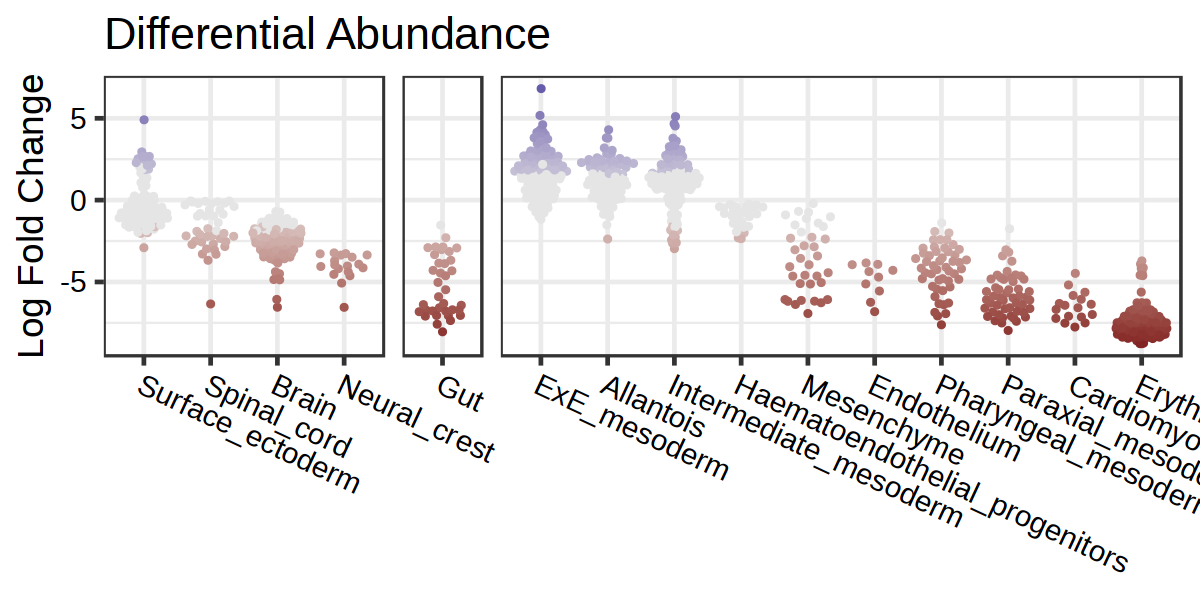

In [99]:
options(repr.plot.width=10, repr.plot.height=5)
p1 = ggplot(to.plot, aes(celltype, logFC, 
        color = logFC_color)) + 
        scale_color_gradient2(mid='grey90') + 
        guides(color = "none") + 
        ylab("Log Fold Change") + 
        ggbeeswarm::geom_quasirandom(alpha = 1) + 
       # coord_flip() + 
        facet_grid(cols=vars(germ_layer), scales='free', space='free') + 
        ggtitle('Differential Abundance') + 
        theme_bw(base_size = 22) + 
        theme(strip.background = element_blank(),
              strip.text = element_blank(),
             axis.text.x=element_text(angle=-25, hjust=0, vjust=1),
             axis.text=element_text(color='black'),
             axis.title.x=element_blank())
p1

In [100]:
outfile = sprintf("%s/results/rna/MiloR/k30_prop0.05/improved_beeswarm.pdf",io$basedir)
pdf(outfile, width=10, height = 5)
    print(p1)
dev.off()

png 
  2

In [ ]:
01_Eomes_RNA/results/rna/MiloR/k30_prop0.05/E8.5_Milo_tdTomcorrFalse_beeswarm_celltype.pdf